# Description

## pIC50 Prediction using Optimized RandomForest

This notebook contains a complete pipeline for training a predictive model for molecular activity (**pIC50**), a key parameter in cheminformatics and drug discovery

**Key Features of the Notebook:**
* **Data Preparation & Feature Engineering:** Loads a structured dataset of molecules with pre-calculated molecular descriptors (features) and the target **pIC50** activity label

* **Machine Learning Pipeline:** Defines a `scikit-learn` pipeline incorporating two main stages:

    1. **Feature Selection:** Uses `SelectKBest` with `f_regression` to select the optimal number of features

    2. **Regression Model:** Implements a `RandomForestRegressor` for activity prediction

* **Hyperparameter Optimization:** Leverages the **Optuna** library to automatically search and tune the model's hyperparameters (including `k` for feature selection, `n_estimators`, and `max_depth`), with the objective of maximizing the cross-validated **$R^2$** score

* **Model Evaluation:** Evaluates the final model performance on a held-out test set, reporting metrics such as **$R^2$** and **RMSE**, and includes a parity plot visualization (Actual vs. Predicted)

* **Prediction on External Data:** Applies the trained and optimized model to two external sets of molecules to generate and save their predicted **pIC50** values

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, 
    mean_squared_error
)

import joblib
import json
import optuna
from optuna.pruners import MedianPruner

# Suppress Optuna's verbose logging, keeping only the most important messages
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('predictions', exist_ok=True)

# RandomForest training

## Data loading and preparation

In [4]:
df = pd.read_csv('dataset.csv', index_col=0)
display(df.head())

,smiles,label,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,FpDensityMorgan2,AvgIpc,BalabanJ,BertzCT,HallKierAlpha,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,...,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_alkyl_halide,fr_allylic_oxid,fr_amidine,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ether,fr_furan,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_morpholine,fr_nitro,fr_nitro_arom,fr_oxazole,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7.387216,13.399867,0.006339,-0.509118,0.583357,14.370370,383.814,1.222222,2.037037,3.105192,1.789174,1105.474623,-3.19,15.617556,23.780266,0.0,0.00000,5.907180,0.000000,4.794537,14.358372,0.000000,0.0,11.600940,49.752414,17.075242,16.159189,9.184952,46.480356,0.000000,14.951936,0.000000,13.847474,10.633577,63.947401,0.000000,10.633577,21.713527,0.000000,...,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,6.769551,13.542332,0.041534,-0.539617,0.489619,16.500000,482.903,1.264706,2.058824,3.360600,1.486357,1332.234815,-3.76,25.254328,29.474194,0.0,0.00000,11.814359,0.000000,9.589074,14.358372,0.000000,0.0,11.600940,42.828677,24.470827,29.372953,18.716352,52.387536,0.000000,19.851845,0.000000,6.923737,36.936854,63.947401,0.000000,10.633577,21.713527,0.000000,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12,5.031517,4.485145,0.423142,0.423142,0.391062,11.035714,369.432,0.928571,1.785714,2.768899,1.558763,1081.620734,-3.87,4.899910,18.689939,0.0,0.00000,0.000000,0.000000,10.409770,9.967957,5.114250,0.0,29.488721,42.464569,24.318126,16.898015,0.000000,28.095560,0.000000,14.951936,10.337503,6.544756,17.373373,84.948129,0.000000,10.325701,17.192635,0.000000,...,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1,3.301030,11.466694,0.035411,-1.026115,0.804599,9.095238,283.287,1.142857,1.714286,2.467695,2.782020,644.889637,-3.12,10.423316,17.711547,0.0,5.90718,0.000000,5.969305,9.589074,0.000000,10.523783,0.0,12.132734,30.193027,12.108208,6.420822,14.695602,23.136976,10.523783,0.000000,0.000000,19.765380,5.316789,35.402024,12.138443,5.316789,5.687386,0.000000,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,O=C(O)/C=C/c1ccc(O)cc1,2.522879,10.103372,0.168958,-0.983264,0.650834,10.333333,164.160,1.250000,1.833333,2.033230,2.772026,298.054616,-1.77,10.213055,5.749512,0.0,0.00000,0.000000,5.969305,0.000000,4.794537,0.000000,0.0,12.132734,23.772206,6.076020,0.000000,15.007592,12.045325,0.000000,0.000000,0.000000,0.000000,0.000000,35.904940,5.749512,0.000000,0.000000,5.749512,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(f'{len(df)} molecules in initial dataset with {len(list(df)) - 2} features')

25478 molecules in initial dataset with 143 features


Extracting features `X` and target value `y`, and performing an 80/20 train/test split

In [6]:
X = df.drop(columns=['smiles', 'label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 20382 | Test: 5096


## Pipeline creation

In [7]:
pipeline = Pipeline([
    ('selector', SelectKBest(score_func=f_regression)),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

## Hyperparameters optimization with `optuna`

In [8]:
def objective(trial: optuna.trial) -> float:
    '''
    Target function for Optuna
    
    Returns: 
        float: the mean cross-validation score
    '''

    # Set space for hyperparameters search

    # Feature selection
    k = trial.suggest_int('n_features', 30, 120, step=10)
    pipeline.set_params(selector__k=k)

    # RandomForest hyperparameters
    params = {
        'regressor__n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'regressor__max_depth': trial.suggest_int('max_depth', 10, 100),
        'regressor__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'regressor__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'regressor__max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'regressor__bootstrap': trial.suggest_categorical('bootstrap', [True, False])
    }

    pipeline.set_params(**params)

    # Cross-validation on training sample with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline, 
        X_train, y_train, 
        cv=kf, 
        scoring='neg_root_mean_squared_error',
        n_jobs=1)
    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    # sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20))
study.optimize(objective, n_trials=100, show_progress_bar=True)

Best trial: 61. Best value: 1.85482: 100%|██████████| 100/100 [4:14:20<00:00, 152.60s/it] 


In [9]:
print(f'Best parameters: {study.best_params}')
print(f'Best RMSE: {study.best_value:.4f}')

Best parameters: {'n_features': 110, 'n_estimators': 1886, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}
Best RMSE: 1.8548


## Training model with best parameters

In [10]:
best_params = study.best_params
pipeline.set_params(
    selector__k=best_params['n_features'],
    regressor__n_estimators=best_params['n_estimators'],
    regressor__max_depth=best_params['max_depth'],
    regressor__min_samples_split=best_params['min_samples_split'],
    regressor__min_samples_leaf=best_params['min_samples_leaf'],
    regressor__max_features=best_params['max_features'],
    regressor__bootstrap=best_params['bootstrap']
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('selector',
                 SelectKBest(k=110,
                             score_func=<function f_regression at 0x7fcdb3f1ae60>)),
                ('regressor',
                 RandomForestRegressor(max_depth=14, max_features='log2',
                                       min_samples_leaf=4, min_samples_split=4,
                                       n_estimators=1886, n_jobs=-1,
                                       random_state=42))])

## Model evaluation on `train` and `test` samples

In [11]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)
    
print(f'\t\tFINAL RESULTS')
print('\nTrain sample:')
print(f'R2: \t{r2_score(y_train, y_train_pred):.4f}')
print(f'RMSE: \t{np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}')

print('\nTest sample')
print(f'R2: \t{r2_score(y_test, y_test_pred):.4f}')
print(f'RMSE: \t{np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}')

		FINAL RESULTS

Train sample:
R2: 	0.4762
RMSE: 	1.6134

Test sample
R2: 	0.3195
RMSE: 	1.8582


Overfitting check

In [12]:
train_test_gap = abs(r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred))
print(f'R2_score gap between train and test: {train_test_gap:.4f}')
if train_test_gap > 0.1:
    print('Warning: Overfitting is possible!')
else:
    print('Overfitting is not found.')

R2_score gap between train and test: 0.1566


## Visualization of model accuracy

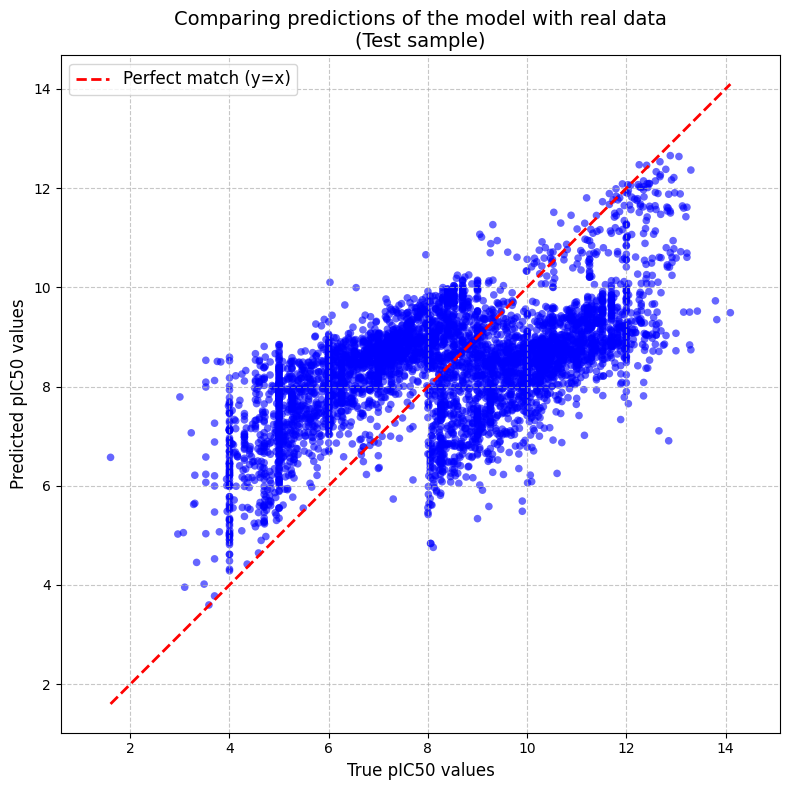

In [13]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.6, color='blue', edgecolors='none', s=30)

# Perfect match line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect match (y=x)')

plt.xlabel('True pIC50 values', fontsize=12)
plt.ylabel('Predicted pIC50 values', fontsize=12)
plt.title('Comparing predictions of the model with real data\n(Test sample)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')

plt.tight_layout()
plt.savefig('models/true_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

## Model and feature names saving

In [14]:
joblib.dump(pipeline, 'models/rf_pipeline.joblib')

['models/rf_pipeline.joblib']

In [15]:
rf_columns = pd.read_csv('dataset.csv', index_col=0) \
        .drop(columns=['smiles', 'label']) \
        .columns \
        .to_list()
with open('models/rf_columns.json', 'w') as f:
    json.dump(rf_columns, f, indent=4)
print(f'Columns from train dataset are saved in rf_columns.json')

Columns from train dataset are saved in rf_columns.json


## Visualization of feature importances (top-20 features)

Extracting indices of chosen features

In [16]:
selector = pipeline.named_steps['selector']
mask = selector.get_support()
selected_features = [col for col, m in zip(df.drop(['smiles', 'label'], axis=1).columns, mask) if m]
importances = pipeline.named_steps['regressor'].feature_importances_

Creating `DataFrame` with importance

In [17]:
feature_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

Visualization

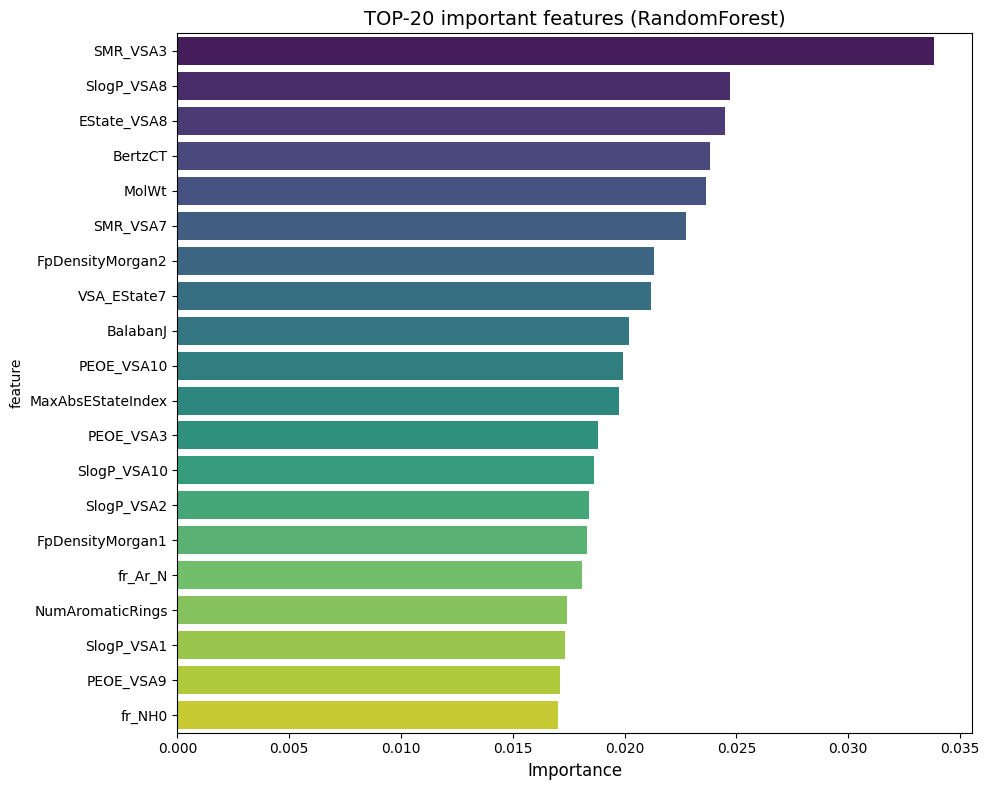

In [18]:
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, y='feature', x='importance', palette='viridis')
plt.title('TOP-20 important features (RandomForest)', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.savefig('models/feature_importance_top20.png', dpi=300)
plt.show()

# Predictions

Model loading

In [19]:
model = joblib.load('models/rf_pipeline.joblib')

In [20]:
with open('models/rf_columns.json', 'r') as f:
    train_cols = json.load(f)

print(f'{len(train_cols)} feature names are extracted')

143 feature names are extracted


## Dataset of molecules with high similarity to learning samples

Data loading

In [21]:
df_to_pred_high = pd.read_csv('data_to_predict_high_similarity.csv', index_col=0)

if 'smiles' not in df_to_pred_high.columns:
    raise ValueError("There is no 'SMILES' column in new data!")

display(df_to_pred_high.head())
print(f'{len(df_to_pred_high)} molecules with high similarity, with {len(list(df_to_pred_high)) - 2} features')

,smiles,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGLO,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi3n,Chi3v,HallKierAlpha,Kappa2,Kappa3,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,...,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_alkyl_halide,fr_allylic_oxid,fr_amidine,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ether,fr_furan,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_morpholine,fr_oxazole,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,C[C@](N)(Cc1ccc(OCc2ccc(Cl)cc2)c(O)c1)C(=O)O,11.038991,0.057729,-1.390753,0.754327,13.347826,335.787,1.217391,1.826087,2.391304,35.495692,9.938229,-2.191215,-2.462932,6.300833,-0.142125,2.473647,2.042985,698.239597,3.390863,3.642839,-2.24,6.894323,4.612346,20.683585,12.145807,11.499024,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,29.800041,42.316108,11.443455,0.000000,19.744455,17.570245,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C[C@](N)(Cc1ccc(OCc2ccccc2)c(O)c1)C(=O)O,11.024450,0.032759,-1.376138,0.761117,13.363636,301.342,1.181818,1.863636,2.454545,16.485229,9.938230,-2.191141,-2.462932,5.779242,-0.142125,2.467024,2.050125,652.963443,3.320430,3.320430,-2.53,6.490713,3.988389,20.683585,12.145807,11.499024,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,36.398202,30.183374,6.420822,0.000000,19.744455,5.969305,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CC1(C)CC[C@]2(C(=O)O)CC[C@]3(C)C(=CC[C@@H]4[C@...,12.762619,0.020449,-0.587725,0.417821,54.058824,472.710,0.941176,1.617647,2.264706,16.368347,9.332233,-2.708488,-2.654908,5.763375,-0.216151,2.761968,1.595458,907.481404,13.183154,13.183154,-0.87,7.340182,2.875856,15.319582,0.000000,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,53.191548,103.621896,5.414990,18.125839,20.114119,5.969305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CC1(C)CC[C@]2(C(=O)O)CC[C@]3(C)C(=CC[C@@H]4[C@...,12.762619,0.020449,-0.587725,0.417821,54.058824,472.710,0.941176,1.617647,2.264706,16.368347,9.332233,-2.708488,-2.654908,5.763375,-0.216151,2.761968,1.595458,907.481404,13.183154,13.183154,-0.87,7.340182,2.875856,15.319582,0.000000,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,53.191548,103.621896,5.414990,18.125839,20.114119,5.969305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CC1(C)CC[C@]2(C(=O)O)CC[C@]3(C)C(=CC[C@@H]4[C@...,12.753229,0.030113,-0.553469,0.409055,52.424242,456.711,0.878788,1.545455,2.212121,16.368274,9.333035,-2.707616,-2.646413,5.763364,-0.205081,2.707834,1.597821,884.972601,13.042127,13.042127,-0.83,6.890065,2.867678,10.213055,0.000000,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,60.115285,109.036887,0.000000,11.518957,15.007592,5.969305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


6244 molecules with high similarity, with 150 features


Number of descriptors differs from training dataset, so we should synchronize feature names

In [22]:
df_high_sync = pd.DataFrame(index=df_to_pred_high.index, columns=train_cols)

for col in train_cols:
    if col in df_to_pred_high.columns:
        df_high_sync[col] = df_to_pred_high[col].values
    else:
        df_high_sync[col] = 0
        print(f"Feature '{col}' missing in new data — filled with 0")

assert df_high_sync.shape[1] == len(train_cols), 'The number of features does not match the training'
print(f'All {len(train_cols)} are present in the right order')

Feature 'VSA_EState10' missing in new data — filled with 0
Feature 'NumSaturatedCarbocycles' missing in new data — filled with 0
Feature 'NumSpiroAtoms' missing in new data — filled with 0
Feature 'fr_nitro' missing in new data — filled with 0
Feature 'fr_nitro_arom' missing in new data — filled with 0
All 143 are present in the right order


In [23]:
df_high_sync = df_high_sync.apply(pd.to_numeric, errors='coerce')

In [24]:
print(f'Size of dataset for prediction: {df_high_sync.shape}\nNumber of features in dataset for prediction: {len(list(df_high_sync))}')

Size of dataset for prediction: (6244, 143)
Number of features in dataset for prediction: 143


Prediction

In [25]:
preds_high = model.predict(df_high_sync)

Saving predictions

In [26]:
df_preds_high = pd.concat([pd.Series(preds_high), df_to_pred_high['smiles']], axis=1).rename({0: "pIC50"}, axis=1)
df_preds_high.to_csv('predictions/preds_high_similarity_rf.csv', index_label=False)
print('Prediction for molecules with high similaruty are saved in preds_high_similarity_rf.csv')

Prediction for molecules with high similaruty are saved in preds_high_similarity_rf.csv


## Dataset of molecules with default similarity to learning samples

Data loading

In [27]:
df_to_pred_def = pd.read_csv('data_to_predict_similarity.csv', index_col=0)

if 'smiles' not in df_to_pred_def.columns:
    raise ValueError("There is no 'SMILES' column in new data!")

display(df_to_pred_def.head())
print(f'{len(df_to_pred_def)} molecules with high similarity, with {len(list(df_to_pred_def)) - 2} fetures')

,smiles,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi3n,Chi3v,HallKierAlpha,Kappa2,Kappa3,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,...,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_aldehyde,fr_alkyl_halide,fr_allylic_oxid,fr_amidine,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ether,fr_furan,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_ketone,fr_ketone_Topliss,fr_methoxy,fr_morpholine,fr_nitro,fr_oxazole,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,C[C@@](N)(Cc1ccc(O)c(O)c1)C(=O)O,10.740383,0.079537,-1.385504,0.543049,14.533333,211.217,1.400000,2.000000,2.466667,16.369297,9.938509,2.277131,-2.185807,-2.462887,5.779108,-0.142124,2.104577,2.905062,387.008820,2.099743,2.099743,-1.75,3.780864,2.599703,21.053250,5.538925,11.499024,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,6.066367,24.619923,6.420822,0.000000,20.114119,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C[C@](N)(Cc1ccc(O)c(Cl)c1)C(=O)O,10.769897,0.032902,-1.333034,0.731490,14.600000,229.663,1.600000,2.200000,2.666667,35.495691,9.940444,2.276431,-2.186258,-2.462980,6.315665,-0.142120,2.104577,2.905062,390.253933,2.072010,2.374743,-1.26,4.082142,2.841823,15.946722,11.288437,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,17.667307,24.619923,6.420822,5.022633,15.007592,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CC1(C)CC[C@]2(C(=O)OCCO)CC[C@]3(C)C(=CC[C@@H]4...,13.631924,0.022243,-0.467517,0.331671,50.567568,516.763,0.945946,1.648649,2.324324,16.541266,9.332169,2.693110,-2.708989,-2.655563,5.784631,-0.216709,2.847735,1.567752,956.825116,13.488197,13.488197,-0.91,8.795706,3.615296,20.056445,6.606882,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,53.191548,103.621896,5.414990,24.732721,24.850982,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,CC1(C)CC[C@]2(C(=O)OCCCO)CC[C@]3(C)C(=CC[C@@H]...,13.777332,0.030253,-0.439456,0.228921,49.552632,530.790,0.947368,1.657895,2.342105,16.535208,9.332168,2.693152,-2.709004,-2.655523,5.784598,-0.216665,2.863873,1.545214,972.431726,13.699361,13.699361,-0.91,9.309433,3.763738,20.056445,0.000000,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,53.191548,103.621896,18.442694,24.732721,24.850982,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CC1(C)CC[C@]2(C(=O)O)CC[C@]3(C)C(=CC[C@@H]4[C@...,12.753229,0.030113,-0.553469,0.409055,52.424242,456.711,0.878788,1.545455,2.212121,16.368274,9.333035,2.687049,-2.707616,-2.646413,5.763364,-0.205081,2.707834,1.597821,884.972601,13.042127,13.042127,-0.83,6.890065,2.867678,10.213055,0.000000,0.000000,0.0,0.0,5.969305,4.794537,0.0,0.0,0.0,60.115285,109.036887,0.000000,11.518957,15.007592,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


7435 molecules with high similarity, with 151 fetures


Number of descriptors differs from training dataset, so we should synchronize feature names

In [28]:
df_def_sync = pd.DataFrame(index=df_to_pred_def.index, columns=train_cols)

for col in train_cols:
    if col in df_to_pred_def.columns:
        df_def_sync[col] = df_to_pred_def[col].values
    else:
        df_def_sync[col] = 0
        print(f"Feature '{col}' missing in new data — filled with 0")

assert df_def_sync.shape[1] == len(train_cols), 'The number of features does not match the training'
print(f'All {len(train_cols)} are present in the right order')

Feature 'NumSaturatedCarbocycles' missing in new data — filled with 0
Feature 'NumSpiroAtoms' missing in new data — filled with 0
Feature 'fr_imide' missing in new data — filled with 0
Feature 'fr_nitro_arom' missing in new data — filled with 0
Feature 'fr_term_acetylene' missing in new data — filled with 0
All 143 are present in the right order


In [29]:
df_def_sync = df_def_sync.apply(pd.to_numeric, errors='coerce')

In [30]:
print(f'Size of dataset for prediction: {df_def_sync.shape}\nNumber of features in dataset for prediction: {len(list(df_def_sync))}')

Size of dataset for prediction: (7435, 143)
Number of features in dataset for prediction: 143


Prediction

In [31]:
preds_def = model.predict(df_def_sync)

Saving predictions

In [32]:
df_preds_def = pd.concat([pd.Series(preds_def), df_to_pred_def['smiles']], axis=1).rename({0: "pIC50"}, axis=1)
df_preds_def.to_csv('predictions/preds_default_similarity_rf.csv', index_label=False)
print('Prediction for molecules with default similaruty are saved in preds_default_similarity_rf.csv')

Prediction for molecules with default similaruty are saved in preds_default_similarity_rf.csv
